In [277]:
import numpy as np
import pandas as pd
from copy import deepcopy
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

def calc_feature(vals, lag, agg, window, i):
    if i - lag - window + 1 < 0:
        return None
    if agg == 'sum':
        ans = sum(vals[i - lag - window + 1:i - lag + 1])
    elif agg == 'mean':
        ans = sum(vals[i - lag - window + 1:i - lag + 1]) / window
    elif agg.startswith('percentile_'):
        prc = int(agg.split('_')[1])
        ans = np.percentile(np.array(vals[i - lag - window + 1:i - lag + 1]), prc)
    else:
        ans = None
    return ans

def lagged_features(data, date_col, cols, lags, agg_methods, windows):
    data = data.sort_values(date_col)
    res = deepcopy(data)

    for col in cols:
        for lag in lags:
            for agg in agg_methods:
                for window in windows:
                    values = []
                    for i in range(len(res)):
                        values.append(calc_feature(res[col].to_list(), lag, agg, window, i))
                    res[f'{col}_lag_{lag}_agg_{agg}_window_{window}'] = values
    
    return res.reset_index()


df = pd.read_pickle('electronika_clean.pkl')
df

,Order_ID,Email_new,Phone_new,Source,OrderDate,время,месяц,ChangeDate,DeliveryDate,PaymentDate,...,Quant,RowPrice,RowDiscount,RowSum,Brand,TN,TK,NomFullPath,Week,Nom_ID
2,1303000509_TT,55666668105117_iu29@yandex.ru,55485656-57565656575275,Онлайн-Резерв.,2016-03-30,08:46:30.000,201603,2016-03-30 09:31:57.000,2016-04-06 00:00:00.000,1900-01-01 00:00:00.000,...,1.0,35999.0,0.0,35999.0,Samsung,ТВ-Аудио,Телевизоры LCD,"Телевизоры, аудио, видео/Телевизоры/Smart теле...",13.0,95567.0
4,1303000510_TT,55666668105117_iu29@yandex.ru,55485656-57565656575275,Онлайн-Резерв.,2016-03-30,11:22:51.000,201603,2016-03-30 11:24:32.000,2016-04-06 00:00:00.000,1900-01-01 00:00:00.000,...,2.0,3990.0,0.0,7980.0,NaN,NaN,NaN,Установка и настройка техники/Установка и наст...,13.0,2748.0
5,1303000510_TT,55666668105117_iu29@yandex.ru,55485656-57565656575275,Онлайн-Резерв.,2016-03-30,11:22:51.000,201603,2016-03-30 11:24:32.000,2016-04-06 00:00:00.000,1900-01-01 00:00:00.000,...,2.0,4490.0,0.0,8980.0,NaN,NaN,NaN,Установка и настройка техники/Установка и наст...,13.0,7874.0
7,1303000510_TT,55666668105117_iu29@yandex.ru,55485656-57565656575275,Онлайн-Резерв.,2016-03-30,11:22:51.000,201603,2016-03-30 11:24:32.000,2016-04-06 00:00:00.000,1900-01-01 00:00:00.000,...,2.0,32999.0,0.0,65998.0,Sony,ТВ-Аудио,Телевизоры LCD,"Телевизоры, аудио, видео/Телевизоры/Smart теле...",13.0,99485.0
8,1303000510_TT,55666668105117_iu29@yandex.ru,55485656-57565656575275,Онлайн-Резерв.,2016-03-30,11:22:51.000,201603,2016-03-30 11:24:32.000,2016-04-06 00:00:00.000,1900-01-01 00:00:00.000,...,2.0,999.0,0.0,1998.0,РЭМО,Аксессуары,Аксессуары ТВ-Аудио,"Телевизоры, аудио, видео/Аксессуары для ТВ/Ант...",13.0,20709.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357019,5898089_BX,6666449117_1u9@bk.ru,55574957-51495048515075,Онлайн-Резерв.,2016-04-30,23:51:37.000,201604,2016-05-03 12:55:07.000,2016-05-02 00:00:00.000,2016-05-02 00:10:22.000,...,1.0,899.0,0.0,899.0,Saturn,Климат,Вентиляторы бытовые,Техника для дома/Климатическая техника/Кондици...,17.0,38755.0
357021,5898095_BX,666661118109_vm27@yahoo.com,55575452-55554849505278,Онлайн-Резерв.,2016-04-30,23:54:03.000,201604,2016-05-04 19:43:40.000,2016-05-07 00:00:00.000,2016-05-04 19:43:41.000,...,1.0,1090.0,0.0,1090.0,Case Logic,Аксессуары,Аксессуары для фото/видео,Фото- и видеотехника/Аксессуары для фото и вид...,17.0,31908.0
357023,5898099_BX,3110116_nt16@pisem.net,55574948-50554849554878,Онлайн-Резерв.,2016-04-30,23:56:02.000,201604,2016-05-01 11:57:42.000,2016-05-08 00:00:00.000,1900-01-01 00:00:00.000,...,1.0,6859.0,0.0,6859.0,ELIKOR,Крупная бытовая техника,Встраиваемая техника,Встраиваемая техника/Вытяжки/,17.0,140459.0
357024,5898102_BX,55666665102117_fu13@list.ru,55575648-51484956545071,Онлайн-Резерв.,2016-04-30,23:56:38.000,201604,2016-05-06 20:18:49.000,2016-05-05 00:00:00.000,2016-05-06 20:18:50.000,...,1.0,9120.0,0.0,9120.0,FORWARD,Спорт и активный отдых,Велосипеды и аксессуары,Товары для спорта и отдыха/Велосипеды и аксесс...,17.0,295956.0


# Без учета внешних факторов

## Крупная бытовая техника

In [278]:
category_name = 'Крупная бытовая техника'

daily_sales = df[df['TN'] == f'{category_name}'][['OrderDate', 'Quant']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1
daily_sales.head(10)

,Quant,weekday,monthday,is_weekend
OrderDate,,,,
2016-03-01,477.0,1,1,0
2016-03-02,460.0,2,2,0
2016-03-03,434.0,3,3,0
2016-03-04,427.0,4,4,0
2016-03-05,735.0,5,5,1
2016-03-06,682.0,6,6,1
2016-03-07,631.0,0,7,0
2016-03-08,496.0,1,8,0
2016-03-09,404.0,2,9,0


In [279]:
cols = ['Quant']
lags = [14, 18, 20]
agg = ['sum', 'mean', 'percentile_50', 'percentile_90']
windows = [1, 7, 10]
date_col = 'OrderDate'

data_features = lagged_features(
    daily_sales, date_col, cols, lags, agg, windows
)
data_features

,OrderDate,Quant,weekday,monthday,is_weekend,Quant_lag_14_agg_sum_window_1,Quant_lag_14_agg_sum_window_7,Quant_lag_14_agg_sum_window_10,Quant_lag_14_agg_mean_window_1,Quant_lag_14_agg_mean_window_7,...,Quant_lag_20_agg_sum_window_10,Quant_lag_20_agg_mean_window_1,Quant_lag_20_agg_mean_window_7,Quant_lag_20_agg_mean_window_10,Quant_lag_20_agg_percentile_50_window_1,Quant_lag_20_agg_percentile_50_window_7,Quant_lag_20_agg_percentile_50_window_10,Quant_lag_20_agg_percentile_90_window_1,Quant_lag_20_agg_percentile_90_window_7,Quant_lag_20_agg_percentile_90_window_10
0,2016-03-01,477.0,1,1,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-03-02,460.0,2,2,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-03-03,434.0,3,3,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-03-04,427.0,4,4,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-03-05,735.0,5,5,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,2016-04-26,530.0,1,26,0,467.0,3405.0,4877.0,467.0,486.428571,...,4492.0,449.0,467.000000,449.2,449.0,418.0,417.5,449.0,590.6,565.4
57,2016-04-27,478.0,2,27,0,453.0,3409.0,4689.0,453.0,487.000000,...,4493.0,439.0,471.714286,449.3,439.0,439.0,417.5,439.0,590.6,565.4
58,2016-04-28,409.0,3,28,0,444.0,3414.0,4715.0,444.0,487.714286,...,4496.0,371.0,469.714286,449.6,371.0,439.0,417.5,371.0,590.6,565.4
59,2016-04-29,365.0,4,29,0,443.0,3486.0,4745.0,443.0,498.000000,...,4697.0,618.0,478.428571,469.7,618.0,439.0,428.5,618.0,627.2,620.3


In [280]:
train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
train_df.fillna(-1000, inplace=True)
test_df.fillna(-1000, inplace=True)
X = train_df.drop(['Quant', 'OrderDate'], axis=1)
y = train_df.Quant

categorical_features_indices = np.where(X.dtypes != float)[0]

model = CatBoostRegressor(
    loss_function='MAPE',
    random_seed=42,
    logging_level='Silent'
)

model.fit(
    X, y,
    cat_features=categorical_features_indices,
    plot=True
)

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48810/709052078.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48810/709052078.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [281]:
X_test = test_df.drop(['Quant', 'OrderDate'], axis=1)
y_test = test_df.Quant
predictions = model.predict(X_test)
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

,Quant,weekday,monthday,is_weekend,Predictions
OrderDate,,,,,
2016-03-01,477.0,1,1,0,-1.000000
2016-03-02,460.0,2,2,0,-1.000000
2016-03-03,434.0,3,3,0,-1.000000
2016-03-04,427.0,4,4,0,-1.000000
2016-03-05,735.0,5,5,1,-1.000000
...,...,...,...,...,...
2016-04-26,530.0,1,26,0,435.038380
2016-04-27,478.0,2,27,0,445.065383
2016-04-28,409.0,3,28,0,443.054377


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48810/1067484517.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


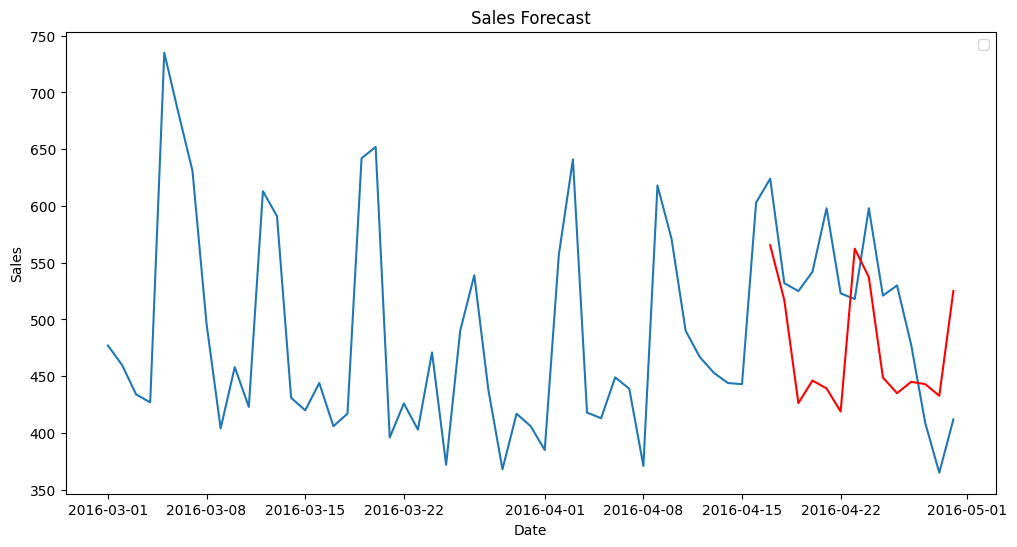

MAE: 75.06240363229043
MSE: 7008.161411581078
MAPE: 14.773759289036972


In [ ]:
# Forecast future values
forecast_periods = 14  # Forecast the next 12 months
forecast = predictions

plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.Quant)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['Quant'][-14:], predictions)
mse = mean_squared_error(daily_sales['Quant'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['Quant'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

## Сделай Сам

In [283]:
category_name = 'Сделай сам'

daily_sales = df[df['TN'] == f'{category_name}'][['OrderDate', 'Quant']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1
daily_sales.head(10)

,Quant,weekday,monthday,is_weekend
OrderDate,,,,
2016-03-01,249.0,1,1,0
2016-03-02,247.0,2,2,0
2016-03-03,269.0,3,3,0
2016-03-04,290.0,4,4,0
2016-03-05,229.0,5,5,1
2016-03-06,208.0,6,6,1
2016-03-07,245.0,0,7,0
2016-03-08,197.0,1,8,0
2016-03-09,314.0,2,9,0


In [284]:
cols = ['Quant']
lags = [14, 18, 20]
agg = ['sum', 'mean', 'percentile_50', 'percentile_90']
windows = [1, 7, 10]
date_col = 'OrderDate'

data_features = lagged_features(
    daily_sales, date_col, cols, lags, agg, windows
)
data_features

,OrderDate,Quant,weekday,monthday,is_weekend,Quant_lag_14_agg_sum_window_1,Quant_lag_14_agg_sum_window_7,Quant_lag_14_agg_sum_window_10,Quant_lag_14_agg_mean_window_1,Quant_lag_14_agg_mean_window_7,...,Quant_lag_20_agg_sum_window_10,Quant_lag_20_agg_mean_window_1,Quant_lag_20_agg_mean_window_7,Quant_lag_20_agg_mean_window_10,Quant_lag_20_agg_percentile_50_window_1,Quant_lag_20_agg_percentile_50_window_7,Quant_lag_20_agg_percentile_50_window_10,Quant_lag_20_agg_percentile_90_window_1,Quant_lag_20_agg_percentile_90_window_7,Quant_lag_20_agg_percentile_90_window_10
0,2016-03-01,249.0,1,1,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-03-02,247.0,2,2,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-03-03,269.0,3,3,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-03-04,290.0,4,4,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-03-05,229.0,5,5,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,2016-04-26,533.0,1,26,0,389.0,2213.0,3132.0,389.0,316.142857,...,2828.0,325.0,289.857143,282.8,325.0,310.0,280.5,325.0,328.6,325.9
57,2016-04-27,387.0,2,27,0,343.0,2231.0,3200.0,343.0,318.714286,...,2872.0,282.0,283.714286,287.2,282.0,282.0,284.0,282.0,328.6,325.9
58,2016-04-28,400.0,3,28,0,445.0,2394.0,3335.0,445.0,342.000000,...,2853.0,256.0,284.571429,285.3,256.0,282.0,284.0,256.0,328.6,325.9
59,2016-04-29,297.0,4,29,0,339.0,2477.0,3340.0,339.0,353.857143,...,2861.0,294.0,296.571429,286.1,294.0,294.0,288.0,294.0,328.6,325.9


In [285]:
train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
train_df.fillna(-1000, inplace=True)
test_df.fillna(-1000, inplace=True)
X = train_df.drop(['Quant', 'OrderDate'], axis=1)
y = train_df.Quant

categorical_features_indices = np.where(X.dtypes != float)[0]

model = CatBoostRegressor(
    loss_function='MAPE',
    random_seed=42,
    logging_level='Silent'
)

model.fit(
    X, y,
    cat_features=categorical_features_indices,
    plot=True
)

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48810/709052078.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48810/709052078.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [286]:
X_test = test_df.drop(['Quant', 'OrderDate'], axis=1)
y_test = test_df.Quant
predictions = model.predict(X_test)
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

,Quant,weekday,monthday,is_weekend,Predictions
OrderDate,,,,,
2016-03-01,249.0,1,1,0,-1.000000
2016-03-02,247.0,2,2,0,-1.000000
2016-03-03,269.0,3,3,0,-1.000000
2016-03-04,290.0,4,4,0,-1.000000
2016-03-05,229.0,5,5,1,-1.000000
...,...,...,...,...,...
2016-04-26,533.0,1,26,0,309.521994
2016-04-27,387.0,2,27,0,297.267005
2016-04-28,400.0,3,28,0,282.072905


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48810/1450528397.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


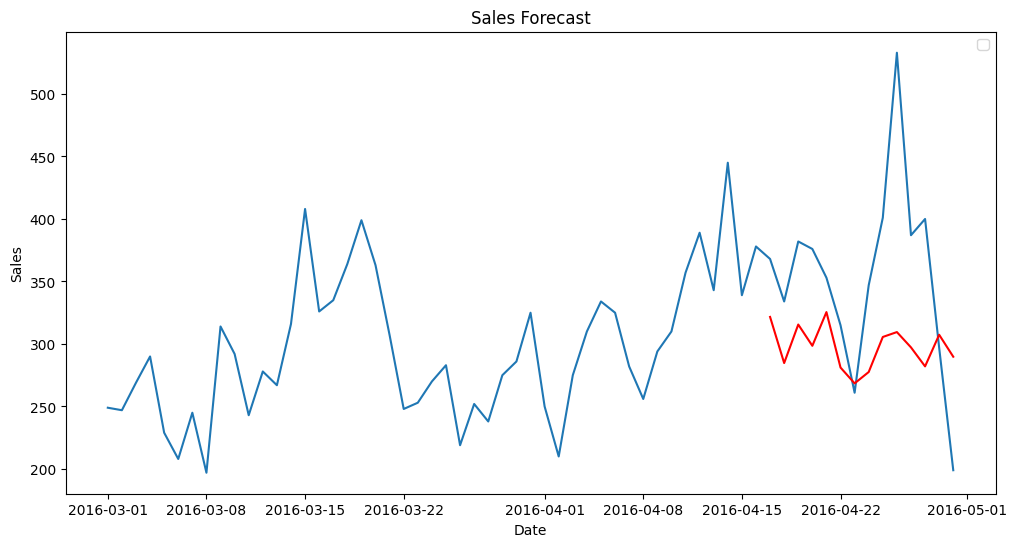

MAE: 71.82352400532929
MSE: 7937.6736596169985
MAPE: 19.590811719346483


In [287]:
forecast_periods = 14
forecast = predictions

plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.Quant)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['Quant'][-14:], predictions)
mse = mean_squared_error(daily_sales['Quant'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['Quant'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

# С учетом акций

In [288]:
actions_values = df['Actions'].value_counts().index
actions_set = set()
for action in actions_values:
    values = action.split(',')
    for value in values:
        actions_set.add(value)

for col in list(actions_set):
    df[col] = df['Actions'].apply(lambda x: int(str(x).find(col) != -1))
df['Quant_action'] = df['Quant'] * df['СкидкаСуммойПроцентомСЛимитом']

## Крупная бытовая техника

In [289]:
category_name = 'Крупная бытовая техника'

daily_sales = df[df['TN'] == f'{category_name}'][['OrderDate', 'Quant']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()
action = df[df['TN'] == category_name][['Quant_action', 'OrderDate']].groupby(['OrderDate']).sum()
action['IsAction'] = (action['Quant_action'] > 10).apply(lambda x: int(x))

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1

daily_sales = daily_sales.join(action[['IsAction']], on='OrderDate')

daily_sales.head(10)

,Quant,weekday,monthday,is_weekend,IsAction
OrderDate,,,,,
2016-03-01,477.0,1,1,0,1
2016-03-02,460.0,2,2,0,1
2016-03-03,434.0,3,3,0,1
2016-03-04,427.0,4,4,0,1
2016-03-05,735.0,5,5,1,1
2016-03-06,682.0,6,6,1,1
2016-03-07,631.0,0,7,0,1
2016-03-08,496.0,1,8,0,1
2016-03-09,404.0,2,9,0,1


In [290]:
cols = ['Quant']
lags = [14, 18, 20]
agg = ['sum', 'mean', 'percentile_50', 'percentile_90']
windows = [1, 7, 10]
date_col = 'OrderDate'

data_features = lagged_features(
    daily_sales, date_col, cols, lags, agg, windows
)
data_features

,OrderDate,Quant,weekday,monthday,is_weekend,IsAction,Quant_lag_14_agg_sum_window_1,Quant_lag_14_agg_sum_window_7,Quant_lag_14_agg_sum_window_10,Quant_lag_14_agg_mean_window_1,...,Quant_lag_20_agg_sum_window_10,Quant_lag_20_agg_mean_window_1,Quant_lag_20_agg_mean_window_7,Quant_lag_20_agg_mean_window_10,Quant_lag_20_agg_percentile_50_window_1,Quant_lag_20_agg_percentile_50_window_7,Quant_lag_20_agg_percentile_50_window_10,Quant_lag_20_agg_percentile_90_window_1,Quant_lag_20_agg_percentile_90_window_7,Quant_lag_20_agg_percentile_90_window_10
0,2016-03-01,477.0,1,1,0,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-03-02,460.0,2,2,0,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-03-03,434.0,3,3,0,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-03-04,427.0,4,4,0,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-03-05,735.0,5,5,1,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,2016-04-26,530.0,1,26,0,0,467.0,3405.0,4877.0,467.0,...,4492.0,449.0,467.000000,449.2,449.0,418.0,417.5,449.0,590.6,565.4
57,2016-04-27,478.0,2,27,0,0,453.0,3409.0,4689.0,453.0,...,4493.0,439.0,471.714286,449.3,439.0,439.0,417.5,439.0,590.6,565.4
58,2016-04-28,409.0,3,28,0,0,444.0,3414.0,4715.0,444.0,...,4496.0,371.0,469.714286,449.6,371.0,439.0,417.5,371.0,590.6,565.4
59,2016-04-29,365.0,4,29,0,0,443.0,3486.0,4745.0,443.0,...,4697.0,618.0,478.428571,469.7,618.0,439.0,428.5,618.0,627.2,620.3


In [291]:
train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
train_df.fillna(-1000, inplace=True)
test_df.fillna(-1000, inplace=True)
X = train_df.drop(['Quant', 'OrderDate'], axis=1)
y = train_df.Quant

categorical_features_indices = np.where(X.dtypes != float)[0]

model = CatBoostRegressor(
    loss_function='MAPE',
    random_seed=42,
    logging_level='Silent'
)

model.fit(
    X, y,
    cat_features=categorical_features_indices,
    plot=True
)

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48810/709052078.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48810/709052078.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [292]:
X_test = test_df.drop(['Quant', 'OrderDate'], axis=1)
y_test = test_df.Quant
predictions = model.predict(X_test)
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

,Quant,weekday,monthday,is_weekend,IsAction,Predictions
OrderDate,,,,,,
2016-03-01,477.0,1,1,0,1,-1.000000
2016-03-02,460.0,2,2,0,1,-1.000000
2016-03-03,434.0,3,3,0,1,-1.000000
2016-03-04,427.0,4,4,0,1,-1.000000
2016-03-05,735.0,5,5,1,1,-1.000000
...,...,...,...,...,...,...
2016-04-26,530.0,1,26,0,0,429.379046
2016-04-27,478.0,2,27,0,0,437.482095
2016-04-28,409.0,3,28,0,0,434.404036


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48810/1450528397.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


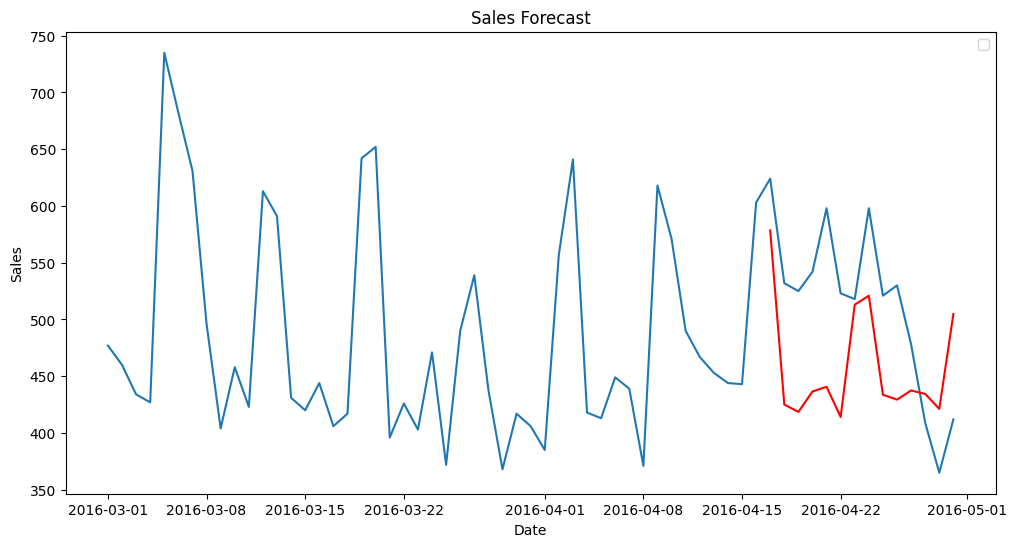

MAE: 79.6815220357887
MSE: 7880.9546466064685
MAPE: 15.46266987375775


In [293]:
forecast_periods = 14
forecast = predictions

plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.Quant)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['Quant'][-14:], predictions)
mse = mean_squared_error(daily_sales['Quant'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['Quant'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

## Сделай Сам

In [294]:
category_name = 'Сделай сам'

daily_sales = df[df['TN'] == f'{category_name}'][['OrderDate', 'Quant']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()
action = df[df['TN'] == category_name][['Quant_action', 'OrderDate']].groupby(['OrderDate']).sum()
action['IsAction'] = (action['Quant_action'] > 10).apply(lambda x: int(x))

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1

daily_sales = daily_sales.join(action[['IsAction']], on='OrderDate')

daily_sales.head(10)

,Quant,weekday,monthday,is_weekend,IsAction
OrderDate,,,,,
2016-03-01,249.0,1,1,0,0
2016-03-02,247.0,2,2,0,0
2016-03-03,269.0,3,3,0,0
2016-03-04,290.0,4,4,0,1
2016-03-05,229.0,5,5,1,1
2016-03-06,208.0,6,6,1,1
2016-03-07,245.0,0,7,0,1
2016-03-08,197.0,1,8,0,1
2016-03-09,314.0,2,9,0,0


In [295]:
cols = ['Quant']
lags = [14, 18, 20]
agg = ['sum', 'mean', 'percentile_50', 'percentile_90']
windows = [1, 7, 10]
date_col = 'OrderDate'

data_features = lagged_features(
    daily_sales, date_col, cols, lags, agg, windows
)
data_features

,OrderDate,Quant,weekday,monthday,is_weekend,IsAction,Quant_lag_14_agg_sum_window_1,Quant_lag_14_agg_sum_window_7,Quant_lag_14_agg_sum_window_10,Quant_lag_14_agg_mean_window_1,...,Quant_lag_20_agg_sum_window_10,Quant_lag_20_agg_mean_window_1,Quant_lag_20_agg_mean_window_7,Quant_lag_20_agg_mean_window_10,Quant_lag_20_agg_percentile_50_window_1,Quant_lag_20_agg_percentile_50_window_7,Quant_lag_20_agg_percentile_50_window_10,Quant_lag_20_agg_percentile_90_window_1,Quant_lag_20_agg_percentile_90_window_7,Quant_lag_20_agg_percentile_90_window_10
0,2016-03-01,249.0,1,1,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-03-02,247.0,2,2,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-03-03,269.0,3,3,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-03-04,290.0,4,4,0,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-03-05,229.0,5,5,1,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,2016-04-26,533.0,1,26,0,1,389.0,2213.0,3132.0,389.0,...,2828.0,325.0,289.857143,282.8,325.0,310.0,280.5,325.0,328.6,325.9
57,2016-04-27,387.0,2,27,0,1,343.0,2231.0,3200.0,343.0,...,2872.0,282.0,283.714286,287.2,282.0,282.0,284.0,282.0,328.6,325.9
58,2016-04-28,400.0,3,28,0,1,445.0,2394.0,3335.0,445.0,...,2853.0,256.0,284.571429,285.3,256.0,282.0,284.0,256.0,328.6,325.9
59,2016-04-29,297.0,4,29,0,0,339.0,2477.0,3340.0,339.0,...,2861.0,294.0,296.571429,286.1,294.0,294.0,288.0,294.0,328.6,325.9


In [296]:
train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
train_df.fillna(-1000, inplace=True)
test_df.fillna(-1000, inplace=True)
X = train_df.drop(['Quant', 'OrderDate'], axis=1)
y = train_df.Quant

categorical_features_indices = np.where(X.dtypes != float)[0]

model = CatBoostRegressor(
    loss_function='MAPE',
    random_seed=42,
    logging_level='Silent'
)

model.fit(
    X, y,
    cat_features=categorical_features_indices,
    plot=True
)

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48810/709052078.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48810/709052078.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [297]:
X_test = test_df.drop(['Quant', 'OrderDate'], axis=1)
y_test = test_df.Quant
predictions = model.predict(X_test)
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

,Quant,weekday,monthday,is_weekend,IsAction,Predictions
OrderDate,,,,,,
2016-03-01,249.0,1,1,0,0,-1.000000
2016-03-02,247.0,2,2,0,0,-1.000000
2016-03-03,269.0,3,3,0,0,-1.000000
2016-03-04,290.0,4,4,0,1,-1.000000
2016-03-05,229.0,5,5,1,1,-1.000000
...,...,...,...,...,...,...
2016-04-26,533.0,1,26,0,1,332.436640
2016-04-27,387.0,2,27,0,1,301.881742
2016-04-28,400.0,3,28,0,1,304.732732


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48810/1450528397.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


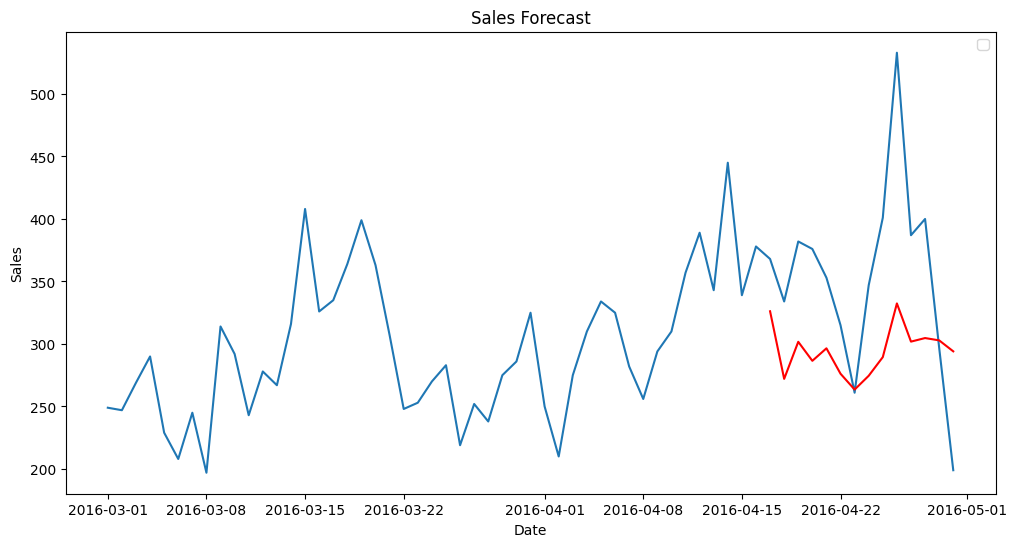

MAE: 74.08469736445677
MSE: 7717.350132693152
MAPE: 20.421101482509194


In [298]:
forecast_periods = 14
forecast = predictions

plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.Quant)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['Quant'][-14:], predictions)
mse = mean_squared_error(daily_sales['Quant'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['Quant'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

# С учетом средней цены проданных товаров

## Крупная бытовая техника

In [299]:
category_name = 'Крупная бытовая техника'

daily_sales = df[df['TN'] == f'{category_name}'][['OrderDate', 'Quant', 'RowSum']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()
daily_sales['RowSum'] /= daily_sales['Quant']
action = df[df['TN'] == category_name][['Quant_action', 'OrderDate']].groupby(['OrderDate']).sum()
action['IsAction'] = (action['Quant_action'] > 10).apply(lambda x: int(x))

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1

daily_sales = daily_sales.join(action[['IsAction']], on='OrderDate')

daily_sales.head(10)

,Quant,RowSum,weekday,monthday,is_weekend,IsAction
OrderDate,,,,,,
2016-03-01,477.0,20634.046122,1,1,0,1
2016-03-02,460.0,17987.978261,2,2,0,1
2016-03-03,434.0,18958.693548,3,3,0,1
2016-03-04,427.0,19199.435597,4,4,0,1
2016-03-05,735.0,19090.391837,5,5,1,1
2016-03-06,682.0,20609.206745,6,6,1,1
2016-03-07,631.0,18430.977813,0,7,0,1
2016-03-08,496.0,18752.548387,1,8,0,1
2016-03-09,404.0,18569.400990,2,9,0,1


In [300]:
cols = ['Quant', 'RowSum']
lags = [14, 18, 20]
agg = ['sum', 'mean', 'percentile_50', 'percentile_90']
windows = [1, 7, 10]
date_col = 'OrderDate'

data_features = lagged_features(
    daily_sales, date_col, cols, lags, agg, windows
)
data_features

,OrderDate,Quant,RowSum,weekday,monthday,is_weekend,IsAction,Quant_lag_14_agg_sum_window_1,Quant_lag_14_agg_sum_window_7,Quant_lag_14_agg_sum_window_10,...,RowSum_lag_20_agg_sum_window_10,RowSum_lag_20_agg_mean_window_1,RowSum_lag_20_agg_mean_window_7,RowSum_lag_20_agg_mean_window_10,RowSum_lag_20_agg_percentile_50_window_1,RowSum_lag_20_agg_percentile_50_window_7,RowSum_lag_20_agg_percentile_50_window_10,RowSum_lag_20_agg_percentile_90_window_1,RowSum_lag_20_agg_percentile_90_window_7,RowSum_lag_20_agg_percentile_90_window_10
0,2016-03-01,477.0,20634.046122,1,1,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-03-02,460.0,17987.978261,2,2,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-03-03,434.0,18958.693548,3,3,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-03-04,427.0,19199.435597,4,4,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-03-05,735.0,19090.391837,5,5,1,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,2016-04-26,530.0,19095.318868,1,26,0,0,467.0,3405.0,4877.0,...,192060.285266,19726.164811,19101.464149,19206.028527,19726.164811,18855.109204,18921.133739,19726.164811,20033.955510,20546.335850
57,2016-04-27,478.0,18774.543933,2,27,0,0,453.0,3409.0,4689.0,...,190331.215598,19273.514806,19194.446559,19033.121560,19273.514806,19273.514806,18921.133739,19273.514806,20033.955510,19803.112485
58,2016-04-28,409.0,18769.254279,3,28,0,0,444.0,3414.0,4715.0,...,191514.954465,19544.032345,19058.502386,19151.495446,19544.032345,19273.514806,19130.336540,19544.032345,19626.098599,19803.112485
59,2016-04-29,365.0,19145.802740,4,29,0,0,443.0,3486.0,4745.0,...,191563.221758,19035.425566,18983.650639,19156.322176,19035.425566,19035.425566,19154.470186,19035.425566,19616.885331,19803.112485


In [301]:
train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
train_df.fillna(-1000, inplace=True)
test_df.fillna(-1000, inplace=True)
X = train_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
y = train_df.Quant

categorical_features_indices = np.where(X.dtypes != float)[0]

model = CatBoostRegressor(
    loss_function='MAPE',
    random_seed=42,
    logging_level='Silent'
)

model.fit(
    X, y,
    cat_features=categorical_features_indices,
    plot=True
)

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48810/768502140.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48810/768502140.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [302]:
X_test = test_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
y_test = test_df.Quant
predictions = model.predict(X_test)
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

,Quant,RowSum,weekday,monthday,is_weekend,IsAction,Predictions
OrderDate,,,,,,,
2016-03-01,477.0,20634.046122,1,1,0,1,-1.000000
2016-03-02,460.0,17987.978261,2,2,0,1,-1.000000
2016-03-03,434.0,18958.693548,3,3,0,1,-1.000000
2016-03-04,427.0,19199.435597,4,4,0,1,-1.000000
2016-03-05,735.0,19090.391837,5,5,1,1,-1.000000
...,...,...,...,...,...,...,...
2016-04-26,530.0,19095.318868,1,26,0,0,442.292444
2016-04-27,478.0,18774.543933,2,27,0,0,443.902887
2016-04-28,409.0,18769.254279,3,28,0,0,439.507220


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48810/1450528397.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


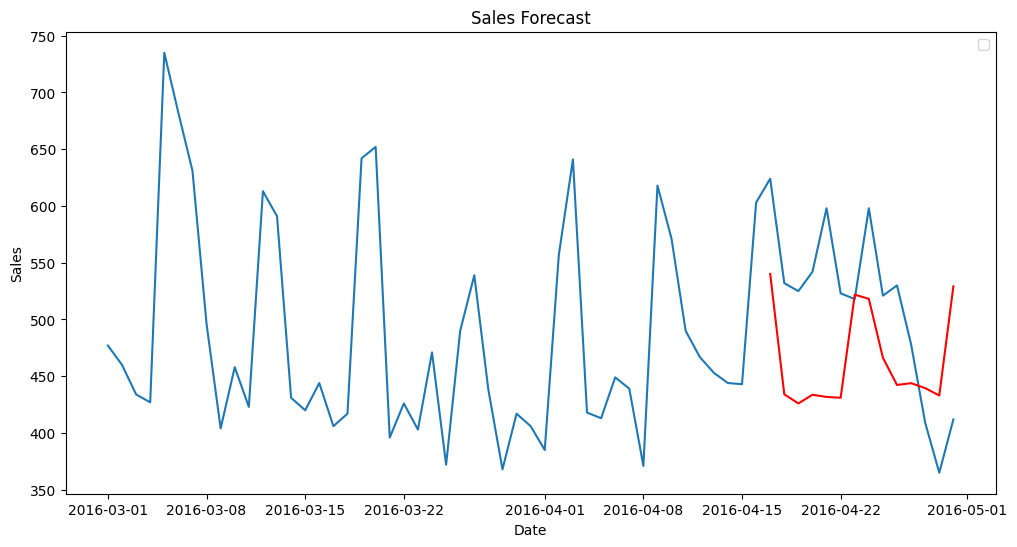

MAE: 80.23187890447403
MSE: 7983.674849364623
MAPE: 15.635345738402009


In [303]:
forecast_periods = 14
forecast = predictions

plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.Quant)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['Quant'][-14:], predictions)
mse = mean_squared_error(daily_sales['Quant'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['Quant'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

## Сделай Сам

In [304]:
category_name = 'Сделай сам'

daily_sales = df[df['TN'] == f'{category_name}'][['OrderDate', 'Quant', 'RowSum']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()
daily_sales['RowSum'] /= daily_sales['Quant']
action = df[df['TN'] == category_name][['Quant_action', 'OrderDate']].groupby(['OrderDate']).sum()
action['IsAction'] = (action['Quant_action'] > 10).apply(lambda x: int(x))

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1

daily_sales = daily_sales.join(action[['IsAction']], on='OrderDate')

daily_sales.head(10)

,Quant,RowSum,weekday,monthday,is_weekend,IsAction
OrderDate,,,,,,
2016-03-01,249.0,6595.947791,1,1,0,0
2016-03-02,247.0,5895.591093,2,2,0,0
2016-03-03,269.0,7017.888476,3,3,0,0
2016-03-04,290.0,5388.437931,4,4,0,1
2016-03-05,229.0,5349.694323,5,5,1,1
2016-03-06,208.0,5940.701923,6,6,1,1
2016-03-07,245.0,5423.787755,0,7,0,1
2016-03-08,197.0,5184.142132,1,8,0,1
2016-03-09,314.0,5105.990446,2,9,0,0


In [305]:
cols = ['Quant', 'RowSum']
lags = [14, 18, 20]
agg = ['sum', 'mean', 'percentile_50', 'percentile_90']
windows = [1, 7, 10]
date_col = 'OrderDate'

data_features = lagged_features(
    daily_sales, date_col, cols, lags, agg, windows
)
data_features

,OrderDate,Quant,RowSum,weekday,monthday,is_weekend,IsAction,Quant_lag_14_agg_sum_window_1,Quant_lag_14_agg_sum_window_7,Quant_lag_14_agg_sum_window_10,...,RowSum_lag_20_agg_sum_window_10,RowSum_lag_20_agg_mean_window_1,RowSum_lag_20_agg_mean_window_7,RowSum_lag_20_agg_mean_window_10,RowSum_lag_20_agg_percentile_50_window_1,RowSum_lag_20_agg_percentile_50_window_7,RowSum_lag_20_agg_percentile_50_window_10,RowSum_lag_20_agg_percentile_90_window_1,RowSum_lag_20_agg_percentile_90_window_7,RowSum_lag_20_agg_percentile_90_window_10
0,2016-03-01,249.0,6595.947791,1,1,0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-03-02,247.0,5895.591093,2,2,0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-03-03,269.0,7017.888476,3,3,0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-03-04,290.0,5388.437931,4,4,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-03-05,229.0,5349.694323,5,5,1,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,2016-04-26,533.0,6360.566604,1,26,0,1,389.0,2213.0,3132.0,...,56909.953763,5269.846154,5503.602386,5690.995376,5269.846154,5269.846154,5725.775344,5269.846154,6450.725560,6461.442777
57,2016-04-27,387.0,7421.994832,2,27,0,1,343.0,2231.0,3200.0,...,56601.249639,6106.195035,5734.468050,5660.124964,6106.195035,5544.770968,5725.775344,6106.195035,6450.725560,6235.920676
58,2016-04-28,400.0,6990.357500,3,28,0,1,445.0,2394.0,3335.0,...,56813.191457,6275.000000,5916.498336,5681.319146,6275.000000,6106.195035,5725.775344,6275.000000,6517.134132,6335.533533
59,2016-04-29,297.0,5758.521886,4,29,0,0,339.0,2477.0,3340.0,...,56368.211057,5461.799320,5816.138375,5636.821106,5461.799320,5544.770968,5503.285144,5461.799320,6517.134132,6335.533533


In [306]:
train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
train_df.fillna(-1000, inplace=True)
test_df.fillna(-1000, inplace=True)
X = train_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
y = train_df.Quant

categorical_features_indices = np.where(X.dtypes != float)[0]

model = CatBoostRegressor(
    loss_function='MAPE',
    random_seed=42,
    logging_level='Silent'
)

model.fit(
    X, y,
    cat_features=categorical_features_indices,
    plot=True
)

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48810/768502140.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48810/768502140.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [307]:
X_test = test_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
y_test = test_df.Quant
predictions = model.predict(X_test)
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

,Quant,RowSum,weekday,monthday,is_weekend,IsAction,Predictions
OrderDate,,,,,,,
2016-03-01,249.0,6595.947791,1,1,0,0,-1.000000
2016-03-02,247.0,5895.591093,2,2,0,0,-1.000000
2016-03-03,269.0,7017.888476,3,3,0,0,-1.000000
2016-03-04,290.0,5388.437931,4,4,0,1,-1.000000
2016-03-05,229.0,5349.694323,5,5,1,1,-1.000000
...,...,...,...,...,...,...,...
2016-04-26,533.0,6360.566604,1,26,0,1,305.564346
2016-04-27,387.0,7421.994832,2,27,0,1,311.630759
2016-04-28,400.0,6990.357500,3,28,0,1,317.391458


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48810/1450528397.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


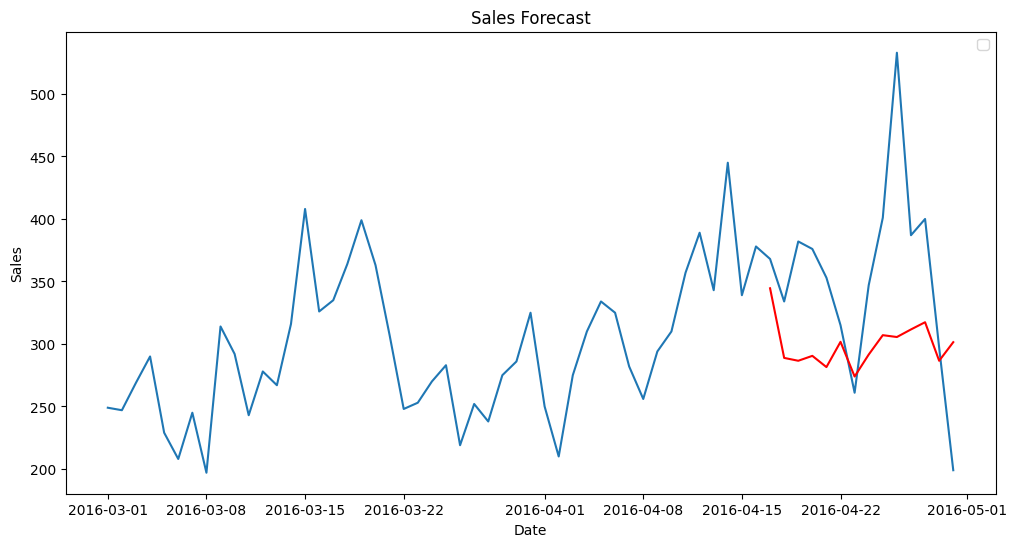

MAE: 71.07182457450425
MSE: 7943.071023245889
MAPE: 19.58992854026071


In [308]:
forecast_periods = 14
forecast = predictions

plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.Quant)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['Quant'][-14:], predictions)
mse = mean_squared_error(daily_sales['Quant'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['Quant'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

# С учетом кластеризации

In [309]:
clustering_results_1 = pd.read_csv('clustering_results_1.csv')
df_clustering_1 = df.join(clustering_results_1[['Phone_new', 'cluster']].set_index('Phone_new'), on='Phone_new')
df_clustering_1['cluster'].value_counts()

cluster
1     107337
8      49173
0      18523
6       6630
2       1500
9       1433
5       1356
12      1248
10       355
13       175
11        11
3          8
4          2
7          1
Name: count, dtype: int64

## Крупная бытовая техника

### Кластер 1

In [310]:
category_name = 'Крупная бытовая техника'
cluster = 1

daily_sales = df_clustering_1[(df_clustering_1['cluster'] == cluster) & (df_clustering_1['TN'] == f'{category_name}')][['OrderDate', 'Quant', 'RowSum']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()
daily_sales['RowSum'] /= daily_sales['Quant']
action = df[df['TN'] == category_name][['Quant_action', 'OrderDate']].groupby(['OrderDate']).sum()
action['IsAction'] = (action['Quant_action'] > 10).apply(lambda x: int(x))

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1

daily_sales = daily_sales.join(action[['IsAction']], on='OrderDate')

daily_sales.head(10)

,Quant,RowSum,weekday,monthday,is_weekend,IsAction
OrderDate,,,,,,
2016-03-01,244.0,17896.356557,1,1,0,1
2016-03-02,269.0,16862.360595,2,2,0,1
2016-03-03,223.0,17375.071749,3,3,0,1
2016-03-04,218.0,17723.449541,4,4,0,1
2016-03-05,417.0,16992.827338,5,5,1,1
2016-03-06,376.0,19114.106383,6,6,1,1
2016-03-07,318.0,16288.949686,0,7,0,1
2016-03-08,273.0,17409.838828,1,8,0,1
2016-03-09,212.0,16141.080189,2,9,0,1


In [311]:
cols = ['Quant', 'RowSum']
lags = [14, 18, 20]
agg = ['sum', 'mean', 'percentile_50', 'percentile_90']
windows = [1, 7, 10]
date_col = 'OrderDate'

data_features = lagged_features(
    daily_sales, date_col, cols, lags, agg, windows
)
data_features

,OrderDate,Quant,RowSum,weekday,monthday,is_weekend,IsAction,Quant_lag_14_agg_sum_window_1,Quant_lag_14_agg_sum_window_7,Quant_lag_14_agg_sum_window_10,...,RowSum_lag_20_agg_sum_window_10,RowSum_lag_20_agg_mean_window_1,RowSum_lag_20_agg_mean_window_7,RowSum_lag_20_agg_mean_window_10,RowSum_lag_20_agg_percentile_50_window_1,RowSum_lag_20_agg_percentile_50_window_7,RowSum_lag_20_agg_percentile_50_window_10,RowSum_lag_20_agg_percentile_90_window_1,RowSum_lag_20_agg_percentile_90_window_7,RowSum_lag_20_agg_percentile_90_window_10
0,2016-03-01,244.0,17896.356557,1,1,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-03-02,269.0,16862.360595,2,2,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-03-03,223.0,17375.071749,3,3,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-03-04,218.0,17723.449541,4,4,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-03-05,417.0,16992.827338,5,5,1,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,2016-04-26,263.0,17630.969582,1,26,0,0,247.0,1736.0,2574.0,...,168985.619975,17099.452991,16594.299678,16898.561998,17099.452991,16862.665761,17061.512255,17099.452991,17235.732848,17569.715835
57,2016-04-27,253.0,17839.988142,2,27,0,0,218.0,1720.0,2424.0,...,166875.684695,16169.729858,16669.535372,16687.568470,16169.729858,16862.665761,16958.845135,16169.729858,17235.732848,17445.220626
58,2016-04-28,211.0,17561.867299,3,28,0,0,214.0,1723.0,2401.0,...,167969.217399,18148.557214,16770.736027,16796.921740,18148.557214,16862.665761,16965.332880,18148.557214,17519.094680,17556.605043
59,2016-04-29,189.0,17241.021164,4,29,0,0,233.0,1755.0,2401.0,...,167774.165866,17295.781046,16803.276176,16777.416587,17295.781046,16862.665761,16965.332880,17295.781046,17636.891513,17510.993090


In [312]:
train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
train_df.fillna(-1000, inplace=True)
test_df.fillna(-1000, inplace=True)
X = train_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
y = train_df.Quant

categorical_features_indices = np.where(X.dtypes != float)[0]

model = CatBoostRegressor(
    loss_function='MAPE',
    random_seed=42,
    logging_level='Silent'
)

model.fit(
    X, y,
    cat_features=categorical_features_indices,
    plot=True
)

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48810/768502140.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48810/768502140.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [313]:
X_test = test_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
y_test = test_df.Quant
predictions = model.predict(X_test)
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

,Quant,RowSum,weekday,monthday,is_weekend,IsAction,Predictions
OrderDate,,,,,,,
2016-03-01,244.0,17896.356557,1,1,0,1,-1.000000
2016-03-02,269.0,16862.360595,2,2,0,1,-1.000000
2016-03-03,223.0,17375.071749,3,3,0,1,-1.000000
2016-03-04,218.0,17723.449541,4,4,0,1,-1.000000
2016-03-05,417.0,16992.827338,5,5,1,1,-1.000000
...,...,...,...,...,...,...,...
2016-04-26,263.0,17630.969582,1,26,0,0,235.114591
2016-04-27,253.0,17839.988142,2,27,0,0,228.118484
2016-04-28,211.0,17561.867299,3,28,0,0,229.648199


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48810/1450528397.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


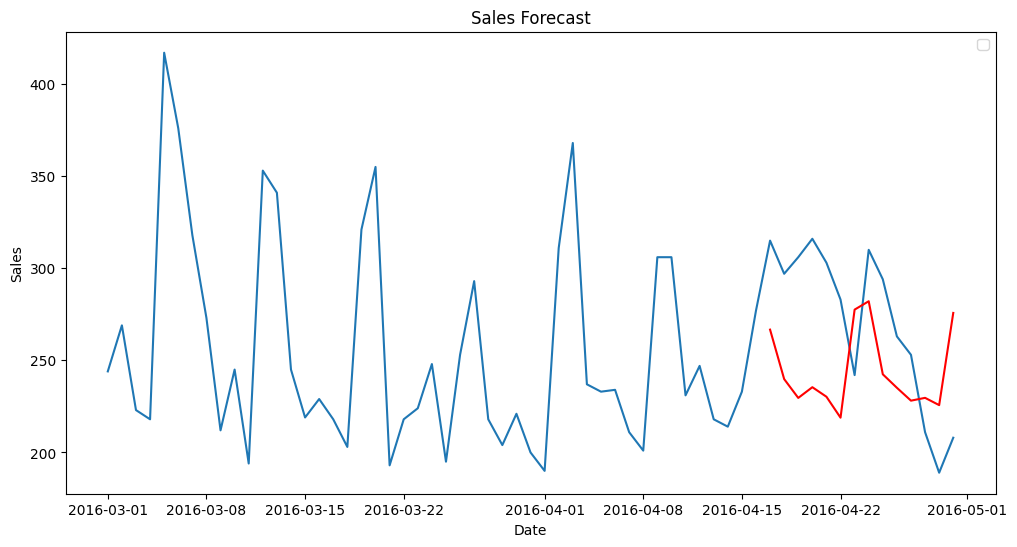

MAE: 49.30019286135106
MSE: 2836.9124088226417
MAPE: 18.157851515850815


In [314]:
forecast_periods = 14
forecast = predictions

plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.Quant)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['Quant'][-14:], predictions)
mse = mean_squared_error(daily_sales['Quant'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['Quant'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

### Кластер 8

In [315]:
category_name = 'Крупная бытовая техника'
cluster = 8

daily_sales = df_clustering_1[(df_clustering_1['cluster'] == cluster) & (df_clustering_1['TN'] == f'{category_name}')][['OrderDate', 'Quant', 'RowSum']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()
daily_sales['RowSum'] /= daily_sales['Quant']
action = df[df['TN'] == category_name][['Quant_action', 'OrderDate']].groupby(['OrderDate']).sum()
action['IsAction'] = (action['Quant_action'] > 10).apply(lambda x: int(x))

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1

daily_sales = daily_sales.join(action[['IsAction']], on='OrderDate')

daily_sales.head(10)

,Quant,RowSum,weekday,monthday,is_weekend,IsAction
OrderDate,,,,,,
2016-03-01,117.0,20908.940171,1,1,0,1
2016-03-02,101.0,17117.514851,2,2,0,1
2016-03-03,97.0,20179.144330,3,3,0,1
2016-03-04,98.0,20093.653061,4,4,0,1
2016-03-05,140.0,20632.514286,5,5,1,1
2016-03-06,96.0,18927.562500,6,6,1,1
2016-03-07,119.0,19008.966387,0,7,0,1
2016-03-08,104.0,17081.201923,1,8,0,1
2016-03-09,88.0,19179.670455,2,9,0,1


In [316]:
cols = ['Quant', 'RowSum']
lags = [14, 18, 20]
agg = ['sum', 'mean', 'percentile_50', 'percentile_90']
windows = [1, 7, 10]
date_col = 'OrderDate'

data_features = lagged_features(
    daily_sales, date_col, cols, lags, agg, windows
)
data_features

,OrderDate,Quant,RowSum,weekday,monthday,is_weekend,IsAction,Quant_lag_14_agg_sum_window_1,Quant_lag_14_agg_sum_window_7,Quant_lag_14_agg_sum_window_10,...,RowSum_lag_20_agg_sum_window_10,RowSum_lag_20_agg_mean_window_1,RowSum_lag_20_agg_mean_window_7,RowSum_lag_20_agg_mean_window_10,RowSum_lag_20_agg_percentile_50_window_1,RowSum_lag_20_agg_percentile_50_window_7,RowSum_lag_20_agg_percentile_50_window_10,RowSum_lag_20_agg_percentile_90_window_1,RowSum_lag_20_agg_percentile_90_window_7,RowSum_lag_20_agg_percentile_90_window_10
0,2016-03-01,117.0,20908.940171,1,1,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-03-02,101.0,17117.514851,2,2,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-03-03,97.0,20179.144330,3,3,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-03-04,98.0,20093.653061,4,4,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-03-05,140.0,20632.514286,5,5,1,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,2016-04-26,139.0,20003.503597,1,26,0,0,84.0,669.0,967.0,...,203678.099131,19933.790698,20723.352246,20367.809913,19933.790698,20765.831858,20132.951953,19933.790698,23068.808313,22427.323046
57,2016-04-27,110.0,19172.827273,2,27,0,0,117.0,700.0,948.0,...,202654.084933,19308.099010,20839.636546,20265.408493,19308.099010,20765.831858,19676.738783,19308.099010,23068.808313,22427.323046
58,2016-04-28,105.0,20440.104762,3,28,0,0,123.0,722.0,978.0,...,203224.607941,19990.209877,20216.555264,20322.460794,19990.209877,19990.209877,19962.000287,19990.209877,21449.874320,22427.323046
59,2016-04-29,87.0,19276.804598,4,29,0,0,93.0,734.0,1002.0,...,206109.811645,21748.037037,20356.870290,20610.981164,21748.037037,19990.209877,20378.020867,21748.037037,21934.220072,22427.323046


In [317]:
train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
train_df.fillna(-1000, inplace=True)
test_df.fillna(-1000, inplace=True)
X = train_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
y = train_df.Quant

categorical_features_indices = np.where(X.dtypes != float)[0]

model = CatBoostRegressor(
    loss_function='MAPE',
    random_seed=42,
    logging_level='Silent'
)

model.fit(
    X, y,
    cat_features=categorical_features_indices,
    plot=True
)

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48810/768502140.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48810/768502140.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [318]:
X_test = test_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
y_test = test_df.Quant
predictions = model.predict(X_test)
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

,Quant,RowSum,weekday,monthday,is_weekend,IsAction,Predictions
OrderDate,,,,,,,
2016-03-01,117.0,20908.940171,1,1,0,1,-1.000000
2016-03-02,101.0,17117.514851,2,2,0,1,-1.000000
2016-03-03,97.0,20179.144330,3,3,0,1,-1.000000
2016-03-04,98.0,20093.653061,4,4,0,1,-1.000000
2016-03-05,140.0,20632.514286,5,5,1,1,-1.000000
...,...,...,...,...,...,...,...
2016-04-26,139.0,20003.503597,1,26,0,0,96.164697
2016-04-27,110.0,19172.827273,2,27,0,0,105.388983
2016-04-28,105.0,20440.104762,3,28,0,0,102.146893


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48810/1450528397.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


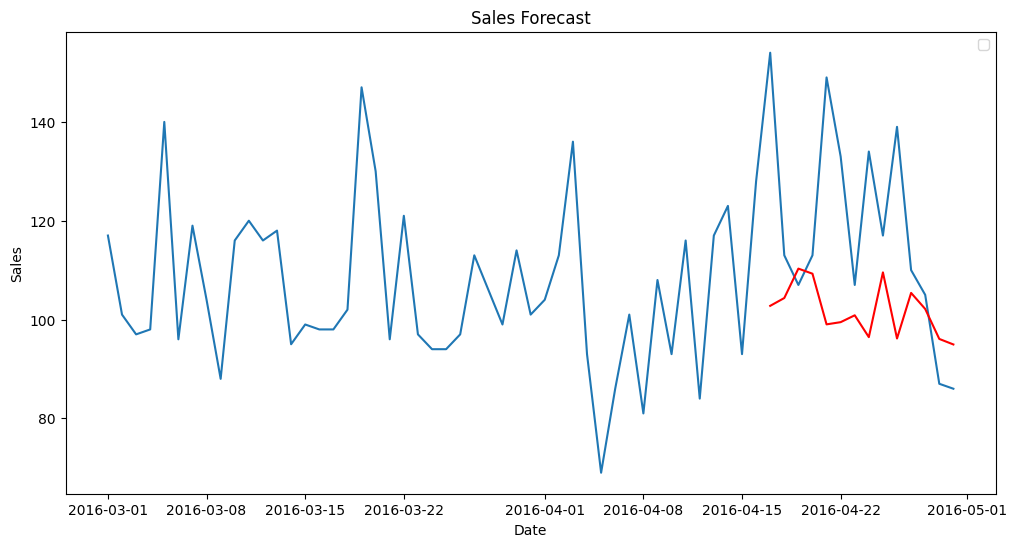

MAE: 19.27787586751407
MSE: 705.4450948454122
MAPE: 14.625761612023256


In [319]:
forecast_periods = 14
forecast = predictions

plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.Quant)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['Quant'][-14:], predictions)
mse = mean_squared_error(daily_sales['Quant'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['Quant'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

## Сделай сам

### Кластер 1

In [320]:
category_name = 'Сделай сам'
cluster = 1

daily_sales = df_clustering_1[(df_clustering_1['cluster'] == cluster) & (df_clustering_1['TN'] == f'{category_name}')][['OrderDate', 'Quant', 'RowSum']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()
daily_sales['RowSum'] /= daily_sales['Quant']
action = df[df['TN'] == category_name][['Quant_action', 'OrderDate']].groupby(['OrderDate']).sum()
action['IsAction'] = (action['Quant_action'] > 10).apply(lambda x: int(x))

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1

daily_sales = daily_sales.join(action[['IsAction']], on='OrderDate')

daily_sales.head(10)

,Quant,RowSum,weekday,monthday,is_weekend,IsAction
OrderDate,,,,,,
2016-03-01,147.0,6419.700680,1,1,0,0
2016-03-02,172.0,5353.924419,2,2,0,0
2016-03-03,185.0,5881.556757,3,3,0,0
2016-03-04,176.0,5563.244318,4,4,0,1
2016-03-05,157.0,4501.458599,5,5,1,1
2016-03-06,145.0,5944.696552,6,6,1,1
2016-03-07,130.0,5807.884615,0,7,0,1
2016-03-08,121.0,4878.347107,1,8,0,1
2016-03-09,177.0,5631.248588,2,9,0,0


In [321]:
cols = ['Quant', 'RowSum']
lags = [14, 18, 20]
agg = ['sum', 'mean', 'percentile_50', 'percentile_90']
windows = [1, 7, 10]
date_col = 'OrderDate'

data_features = lagged_features(
    daily_sales, date_col, cols, lags, agg, windows
)
data_features

,OrderDate,Quant,RowSum,weekday,monthday,is_weekend,IsAction,Quant_lag_14_agg_sum_window_1,Quant_lag_14_agg_sum_window_7,Quant_lag_14_agg_sum_window_10,...,RowSum_lag_20_agg_sum_window_10,RowSum_lag_20_agg_mean_window_1,RowSum_lag_20_agg_mean_window_7,RowSum_lag_20_agg_mean_window_10,RowSum_lag_20_agg_percentile_50_window_1,RowSum_lag_20_agg_percentile_50_window_7,RowSum_lag_20_agg_percentile_50_window_10,RowSum_lag_20_agg_percentile_90_window_1,RowSum_lag_20_agg_percentile_90_window_7,RowSum_lag_20_agg_percentile_90_window_10
0,2016-03-01,147.0,6419.700680,1,1,0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-03-02,172.0,5353.924419,2,2,0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-03-03,185.0,5881.556757,3,3,0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-03-04,176.0,5563.244318,4,4,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-03-05,157.0,4501.458599,5,5,1,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,2016-04-26,324.0,6109.888889,1,26,0,1,195.0,1218.0,1740.0,...,55466.290549,5489.530055,5330.123942,5546.629055,5489.530055,5175.801205,5533.927448,5489.530055,6220.523579,6375.408552
57,2016-04-27,242.0,6876.896694,2,27,0,1,205.0,1240.0,1771.0,...,55411.267233,6156.638554,5580.900394,5541.126723,6156.638554,5489.530055,5533.927448,6156.638554,6280.046869,6375.408552
58,2016-04-28,222.0,6465.171171,3,28,0,1,185.0,1259.0,1790.0,...,55867.962392,6035.020000,5781.447707,5586.796239,6035.020000,6035.020000,5762.275027,6035.020000,6280.046869,6375.408552
59,2016-04-29,169.0,5799.473373,4,29,0,0,195.0,1304.0,1803.0,...,54796.802880,5294.276730,5672.425373,5479.680288,5294.276730,5489.530055,5391.903392,5294.276730,6280.046869,6187.490633


In [322]:
train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
train_df.fillna(-1000, inplace=True)
test_df.fillna(-1000, inplace=True)
X = train_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
y = train_df.Quant

categorical_features_indices = np.where(X.dtypes != float)[0]

model = CatBoostRegressor(
    loss_function='MAPE',
    random_seed=42,
    logging_level='Silent'
)

model.fit(
    X, y,
    cat_features=categorical_features_indices,
    plot=True
)

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48810/768502140.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48810/768502140.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [323]:
X_test = test_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
y_test = test_df.Quant
predictions = model.predict(X_test)
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

,Quant,RowSum,weekday,monthday,is_weekend,IsAction,Predictions
OrderDate,,,,,,,
2016-03-01,147.0,6419.700680,1,1,0,0,-1.000000
2016-03-02,172.0,5353.924419,2,2,0,0,-1.000000
2016-03-03,185.0,5881.556757,3,3,0,0,-1.000000
2016-03-04,176.0,5563.244318,4,4,0,1,-1.000000
2016-03-05,157.0,4501.458599,5,5,1,1,-1.000000
...,...,...,...,...,...,...,...
2016-04-26,324.0,6109.888889,1,26,0,1,158.663430
2016-04-27,242.0,6876.896694,2,27,0,1,161.496474
2016-04-28,222.0,6465.171171,3,28,0,1,160.881558


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48810/1450528397.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


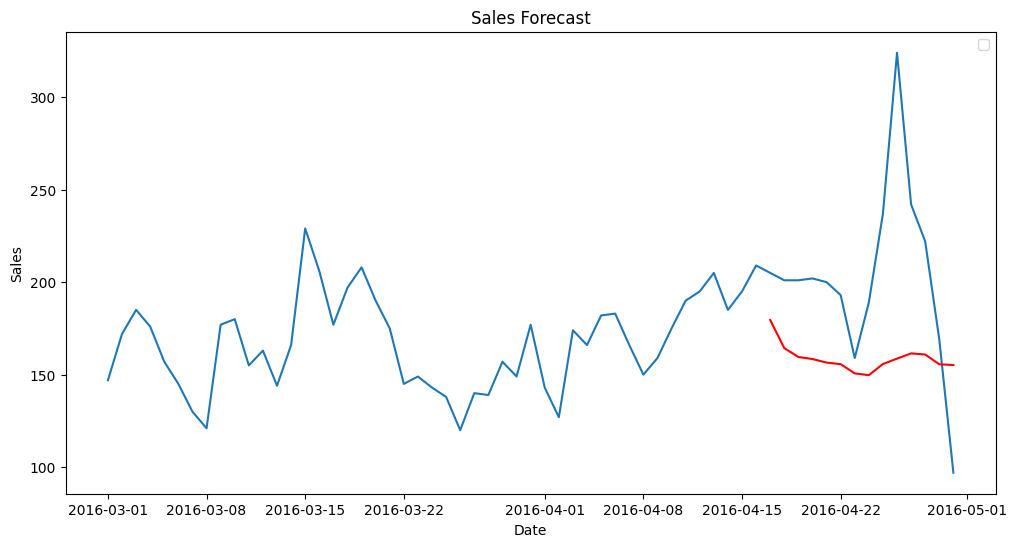

MAE: 52.523643358381086
MSE: 4158.978309049882
MAPE: 25.284209081275478


In [324]:
forecast_periods = 14
forecast = predictions

plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.Quant)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['Quant'][-14:], predictions)
mse = mean_squared_error(daily_sales['Quant'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['Quant'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

### Кластер 8

In [325]:
category_name = 'Сделай сам'
cluster = 8

daily_sales = df_clustering_1[(df_clustering_1['cluster'] == cluster) & (df_clustering_1['TN'] == f'{category_name}')][['OrderDate', 'Quant', 'RowSum']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()
daily_sales['RowSum'] /= daily_sales['Quant']
action = df[df['TN'] == category_name][['Quant_action', 'OrderDate']].groupby(['OrderDate']).sum()
action['IsAction'] = (action['Quant_action'] > 10).apply(lambda x: int(x))

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1

daily_sales = daily_sales.join(action[['IsAction']], on='OrderDate')

daily_sales.head(10)

,Quant,RowSum,weekday,monthday,is_weekend,IsAction
OrderDate,,,,,,
2016-03-01,66.0,7584.181818,1,1,0,0
2016-03-02,43.0,8753.023256,2,2,0,0
2016-03-03,51.0,9339.333333,3,3,0,0
2016-03-04,56.0,6400.660714,4,4,0,1
2016-03-05,38.0,9091.578947,5,5,1,1
2016-03-06,42.0,5573.380952,6,6,1,1
2016-03-07,39.0,10582.230769,0,7,0,1
2016-03-08,35.0,7781.171429,1,8,0,1
2016-03-09,94.0,4578.031915,2,9,0,0


In [326]:
cols = ['Quant', 'RowSum']
lags = [14, 18, 20]
agg = ['sum', 'mean', 'percentile_50', 'percentile_90']
windows = [1, 7, 10]
date_col = 'OrderDate'

data_features = lagged_features(
    daily_sales, date_col, cols, lags, agg, windows
)
data_features

,OrderDate,Quant,RowSum,weekday,monthday,is_weekend,IsAction,Quant_lag_14_agg_sum_window_1,Quant_lag_14_agg_sum_window_7,Quant_lag_14_agg_sum_window_10,...,RowSum_lag_20_agg_sum_window_10,RowSum_lag_20_agg_mean_window_1,RowSum_lag_20_agg_mean_window_7,RowSum_lag_20_agg_mean_window_10,RowSum_lag_20_agg_percentile_50_window_1,RowSum_lag_20_agg_percentile_50_window_7,RowSum_lag_20_agg_percentile_50_window_10,RowSum_lag_20_agg_percentile_90_window_1,RowSum_lag_20_agg_percentile_90_window_7,RowSum_lag_20_agg_percentile_90_window_10
0,2016-03-01,66.0,7584.181818,1,1,0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-03-02,43.0,8753.023256,2,2,0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-03-03,51.0,9339.333333,3,3,0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-03-04,56.0,6400.660714,4,4,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-03-05,38.0,9091.578947,5,5,1,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,2016-04-26,105.0,9804.104762,1,26,0,1,113.0,550.0,740.0,...,82996.879951,8002.810811,8177.637547,8299.687995,8002.810811,8002.810811,8045.488739,8002.810811,10387.008396,10671.121006
57,2016-04-27,108.0,8480.740741,2,27,0,1,95.0,571.0,768.0,...,83545.187861,8636.474576,8472.387161,8354.518786,8636.474576,8636.474576,8319.642694,8636.474576,10387.008396,10671.121006
58,2016-04-28,108.0,9786.120370,3,28,0,1,88.0,600.0,801.0,...,81002.295803,8095.268657,8696.547990,8100.229580,8095.268657,8636.474576,8049.039734,8095.268657,10387.008396,10096.630775
59,2016-04-29,102.0,5674.588235,4,29,0,0,66.0,599.0,799.0,...,81664.521849,7689.315789,8470.760350,8166.452185,7689.315789,8095.268657,8049.039734,7689.315789,10387.008396,10096.630775


In [327]:
train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
train_df.fillna(-1000, inplace=True)
test_df.fillna(-1000, inplace=True)
X = train_df.drop(['Quant', 'OrderDate', 'RowSum'], axis=1)
y = train_df.Quant

categorical_features_indices = np.where(X.dtypes != float)[0]

model = CatBoostRegressor(
    loss_function='MAPE',
    random_seed=42,
    logging_level='Silent'
)

model.fit(
    X, y,
    cat_features=categorical_features_indices,
    plot=True
)

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48810/1978609192.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48810/1978609192.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [328]:
X_test = test_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
y_test = test_df.Quant
predictions = model.predict(X_test)
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

,Quant,RowSum,weekday,monthday,is_weekend,IsAction,Predictions
OrderDate,,,,,,,
2016-03-01,66.0,7584.181818,1,1,0,0,-1.000000
2016-03-02,43.0,8753.023256,2,2,0,0,-1.000000
2016-03-03,51.0,9339.333333,3,3,0,0,-1.000000
2016-03-04,56.0,6400.660714,4,4,0,1,-1.000000
2016-03-05,38.0,9091.578947,5,5,1,1,-1.000000
...,...,...,...,...,...,...,...
2016-04-26,105.0,9804.104762,1,26,0,1,64.567996
2016-04-27,108.0,8480.740741,2,27,0,1,65.751965
2016-04-28,108.0,9786.120370,3,28,0,1,63.856334


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48810/1450528397.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


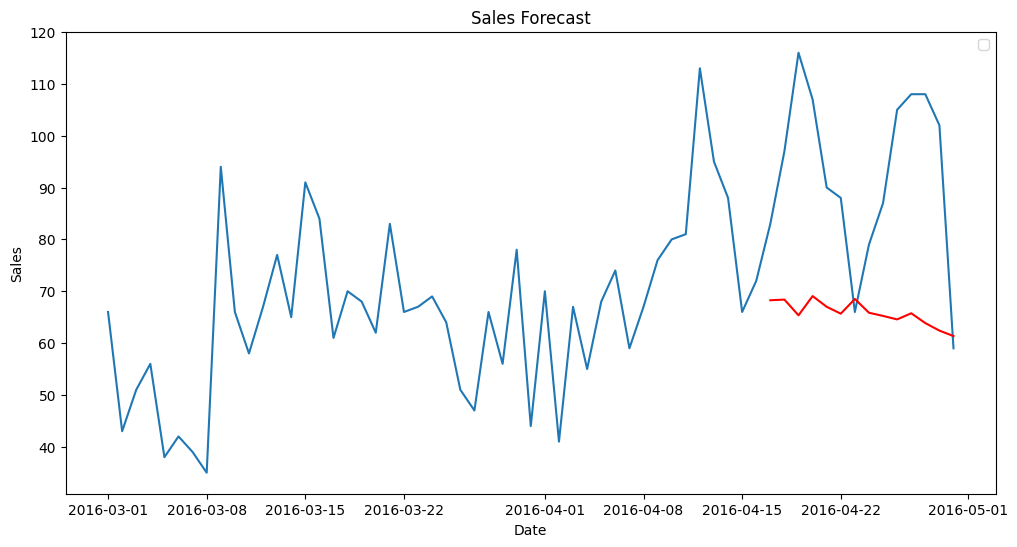

MAE: 27.388408147273257
MSE: 975.770481786935
MAPE: 27.432051697623


In [329]:
forecast_periods = 14
forecast = predictions

plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.Quant)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['Quant'][-14:], predictions)
mse = mean_squared_error(daily_sales['Quant'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['Quant'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')